# Week 2 In-Class Activities:

## Descriptive Statistics of Global Climate Model Output

We are going to take a look at output from a global climate model, the Community Earth System Model (CESM). The data are **globally and annually averaged surface temperature** for a pre-industrial integration (GHGs, etc. fixed at year 1850 values) and a set of 30 individual integrations from 1920-2100.

This activity is adapted from Prof. Jennifer Kay's Objective Data Analysis course at CU Boulder (Originally coded by Prof. Jennifer Kay (CU Boulder) with input from Elizabeth Maroon (CU ATOC/CIRES Postdoc 2018))

First, we import the packages that we will need. Make sure that you have installed the netCDF4 package.

In [16]:
#  import packages
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rc('font',size=12) #  set default font size and weight for plots
from netCDF4 import Dataset #  we need this package to read in the GCM data

Next, we read in the GCM data. The GCM data is stored in a file type called "netCDF". This is a very common climate data file type. To learn more about this file type, check out the following [link](https://climatedataguide.ucar.edu/climate-data-tools-and-analysis/netcdf-overview#:~:text=NetCDF%20). 

Download the first file [here](https://github.com/kls2177/ccia_files/blob/master/TS_timeseries_cesmle_1850.nc?raw=true) and the second file [here](https://github.com/kls2177/ccia_files/blob/master/TS_timeseries_cesmle_1920_2100.nc?raw=true).

In [ ]:
#  Read in the data from netcdf files
#  These data are global annual mean surface temperatures from the CESM Large Ensemble (LENS) Project.

# Read in 20th and 21st century integrations. There are 30 individual integrations of 181 years each.
fname1="/Users/karensmith/Dropbox/EES1132/Fall2020/Activities/Week2/TS_timeseries_cesmle_1920_2100.nc" # filename
nc1 = Dataset(fname1) #  read in file

Now, let's extract the variable we want. netcdf files typically contain more than one variable.

In [17]:
TS_lens = nc1.variables["gts_ann_allcesmle"][:] #  Extract variable we want. Note: TS_lens is a numpy array
year = nc1.variables["year"][:] #  Extract another variable

In [18]:
print(nc1)

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    case: CESM-LE members 1-30
    creation_date: Tue Aug  1 14:17:35 MDT 2017
    source: ATOC4500_hw5_timeseries.ncl
    dimensions(sizes): case(0), member(30), year(181)
    variables(dimensions): float32 gts_ann_allcesmle(member, year), int32 member(member), int32 year(year), float32 ats_ann_allcesmle(member, year)
    groups: 


How would you check that you have 30 integrations of 181 years each?

In [12]:
year

masked_array(data=[1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928,
                   1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937,
                   1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946,
                   1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955,
                   1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964,
                   1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973,
                   1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
                   1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
                   1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
                   2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                   2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
                   2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027,
                   2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036,
                   2037, 2038, 2039, 2040, 2041, 20

In [13]:
#  check that you have the right dimensions to your data
TS_lens.shape

(30, 181)

In [14]:
#  Read in the pre-industrial control integration. There are 1801 years of this integration.
fname2="TS_timeseries_cesmle_1850.nc"
nc2 = Dataset(fname2)

#  Extract gts variable
TS_PI = nc2.variables["gts_annual"][:]

In [15]:
#  check that you have the right dimensions to your data
TS_PI.shape

(1801,)

## I. Preliminary Data Visualization

One of the first things we should always do when analyzing a data set is to first take a look at the raw data.

Let's plot the time series of surface temperature in these integrations. First, let's just plot the pre-industrial control integration.

Text(0.5, 0, 'year')

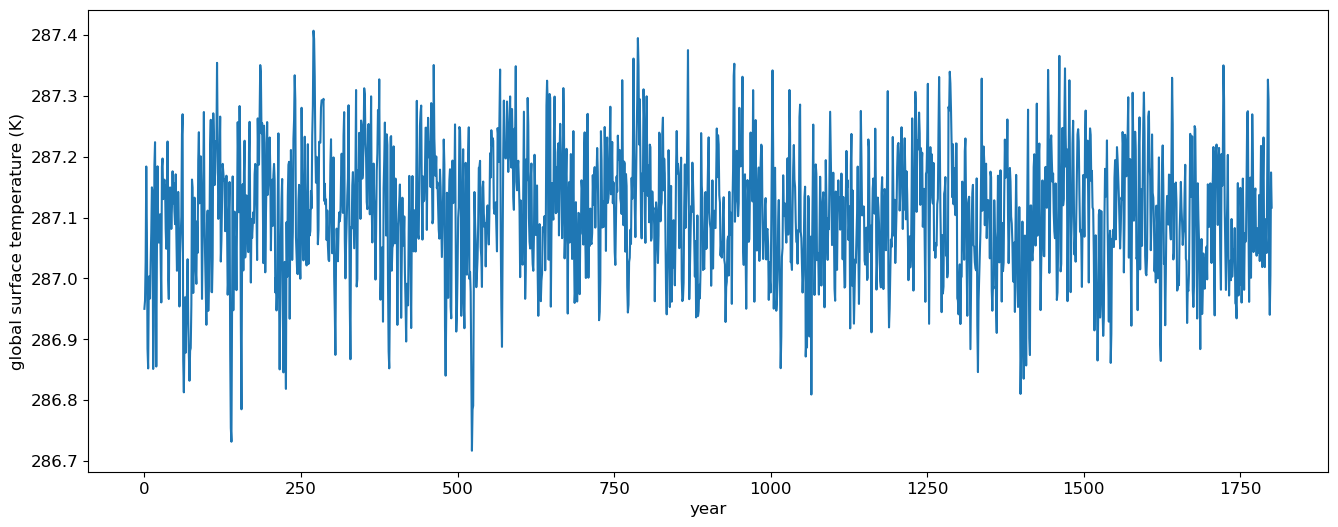

In [19]:
#  It's always a good idea to plot your data before you start doing any calculations.  "Look at your data"!
#  Let's make a line plot of the global annual mean temperature timeseries from the 1850 control. Note the units!

fig = plt.figure(figsize=(16,6))
plt.plot(TS_PI)
plt.ylabel('global surface temperature (K)')
plt.xlabel('year')

**Reflection Question:**

Describe what you see. What is the sampling rate of the data? What do the wiggles in the data represent?

Now, let's add the 20th and 21st century integrations (note that the 21st century integrations follow the high-carbon, RCP8.5 scenario).

We have 30 individual integrations. Normally, I would say to plot each one to make sure the data looks ok, but in this case, these integrations have already been scientifically validated, so we can skip that step.

Let's plot the mean of the 30 integrations. Let's compute the mean over these 30 integrations - how would you do this?

In [8]:
#  compute the 30-member ensemble mean (use the np.mean() function)

TS_lens_mean = np.mean(TS_lens,axis=0)
print(TS_lens_mean.shape)

(181,)


**Note:** Let's plot in degrees Celcius (i.e, if the data are in Kelvin, subtract 273.15)

(0, 2100)

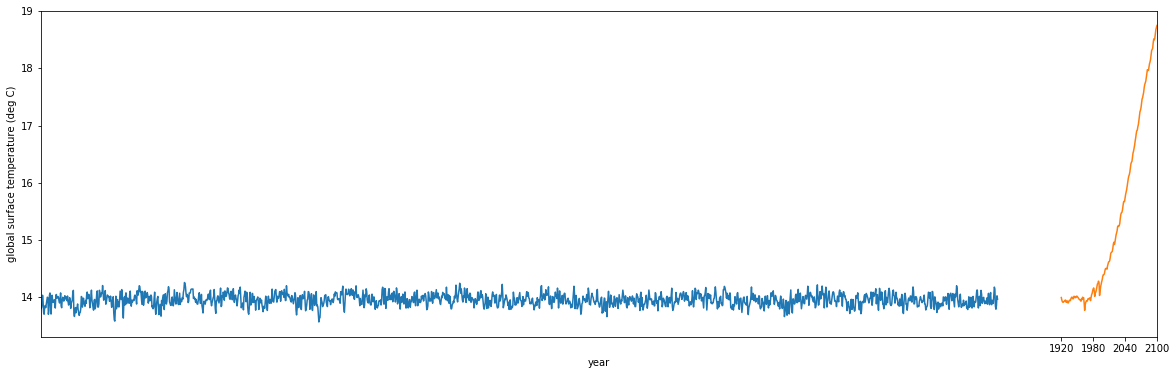

In [9]:
fig = plt.figure(figsize=(20,6))
plt.plot(TS_PI-273.15) # plot pre-industrial TS
plt.ylabel('global surface temperature (deg C)')
plt.xlabel('year')

plt.plot(year,TS_lens_mean-273.15) # plot 20th and 21st century TS
plt.xticks(np.arange(1920,2101,60),["1920","1980","2040","2100"])
plt.xlim(0,2100) # force plot to start and stop at certain x-values

**Reflection Question:**

Why does the variability of the pre-industrial look different from the variability of the 20th and 21st centuries?

## II. Summary Statistics

The primary reason that the CESM Large Ensemble Project exists is to establish the influence of internal climate variability on climate change projections. So, let's take a look at the variability.

But first, let's start with some basic descriptive statistics. Let's calculate the mean of the pre-industrial control integration. We already have a good sense of what this might be from the plot above.

In [10]:
#  Mean pre-industrial surface temperature 

avg_TS_PI = np.mean(TS_PI) - 273.15
print(avg_TS_PI)

13.955224609375023


**Reflection Question:**

Does this seem consistent with your timeseries plot above?

We can do the same thing for our 20th and 21st century data. Let's take a look at the means over two distinct time periods:

- the end of the 20th century: 1980-2005
- the end of the 21st century: 2075-2100

You will need to use **slicing** to extract the time periods of interest and compute the mean values. You can use the variable `year` to see if you are slicing correctly.

In [11]:
TS_lens.shape

(30, 181)

In [12]:
year[155:181]

array([2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085,
       2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096,
       2097, 2098, 2099, 2100], dtype=int32)

In [27]:
#  Mean of 1980-2005 time period. 
#  Compute the mean across the 26-year time period but not the mean across the 30 ensemble members.

avg_TS_19802005 = np.mean(TS_lens[:,60:86],axis=1)
print(avg_TS_19802005)

#  Mean of 2075-2100 time period. 
#  Compute the mean across the 26-year time period but not the mean across the 30 ensemble members.

avg_TS_20752100 = np.mean(TS_lens[:,-25:],axis=1)
print(avg_TS_20752100.shape)

[287.39426 287.35226 287.38873 287.41095 287.46207 287.38757 287.362
 287.3944  287.38306 287.3996  287.39023 287.38992 287.42502 287.33356
 287.4031  287.39    287.4485  287.42316 287.40573 287.33102 287.40344
 287.44122 287.4228  287.4007  287.4284  287.3699  287.45914 287.45834
 287.4307  287.3938 ]
(30,)


**Reflection Question:**
How many means do you have for each time period? 

## III. The "Spread" in the Data

After, having taken a look at the basic summary statistics, let's move on the describing the "spread" in the data.

We quantify the "spread" using the variance or standard deviation. Let's take a look at the standard deviation of the pre-industrial surface temperatures.

In [62]:
# Standard deviation of pre-industrial surface temperature

std_TS_PI = np.std(TS_PI)
print(std_TS_PI)

0.103609964


We can also compute the spread in the 1980-2005 and 2075-2100 means across the 30-member ensemble of integrations. Let's see how these standard deviations compare to the pre-industrail control standard deviation.

In [63]:
# Standard deviation of 1980-2005 means across the 30-member ensemble. 

std_TS_19802005 = np.std(avg_TS_19802005)
print(std_TS_19802005)

# Standard deviation of 2075-2100 means across the 30-member ensemble. 

std_TS_20752100 = np.std(avg_TS_20752100)
print(std_TS_20752100)

0.033138607
0.036997832


**Reflection Question:**

Why do you think the spread in the data is smaller for the 20th and 21st century time periods compared to the pre-industrial? Is there a way you could alter the way you have computed the standard deviation for the 20th and 21st centuries for a cleaner comparison?

## IV. The Shape of the Data

Now, let's visualize these summary statistics using a histogram. Plot the histogram using `plt.hist()` and add vertical lines showing the mean and $\pm$ one standard deviation using `plt.axvline()`. 

Text(0.5,1,'Histogram of annual global surface temperatures for the pre-industrial')

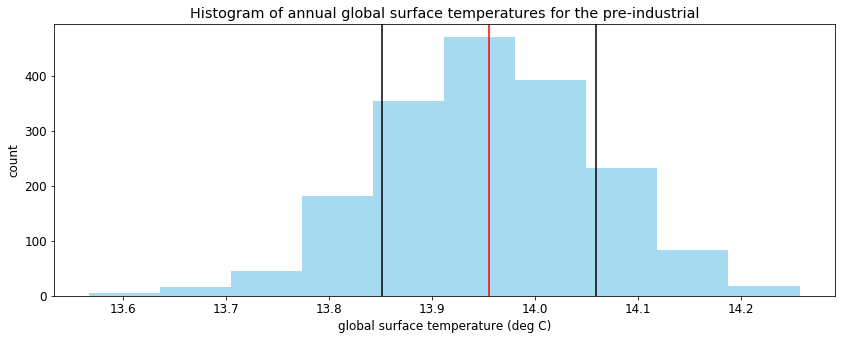

In [100]:
# create a histogram of pre-industrial surface temperatures
plt.figure(figsize=(14,5))
plt.hist(TS_PI-273.15,color='skyblue',alpha=0.75)
plt.axvline(avg_TS_PI,color='r') # plot vertical line for mean
plt.axvline(avg_TS_PI+std_TS_PI,color='k') # plot vertical line for +1 std
plt.axvline(avg_TS_PI-std_TS_PI,color='k') # plot vertical line for -1 std

plt.ylabel("count")
plt.xlabel("global surface temperature (deg C)")
plt.title("Histogram of annual global surface temperatures for the pre-industrial")

For comparison, let's plot the histograms of the 1980-2005 and 2075-2100 surface temperatures across the 30-member ensemble. 

Text(0.5,1,'(b) Histogram of 2075-2100 surface temperature for LENS')

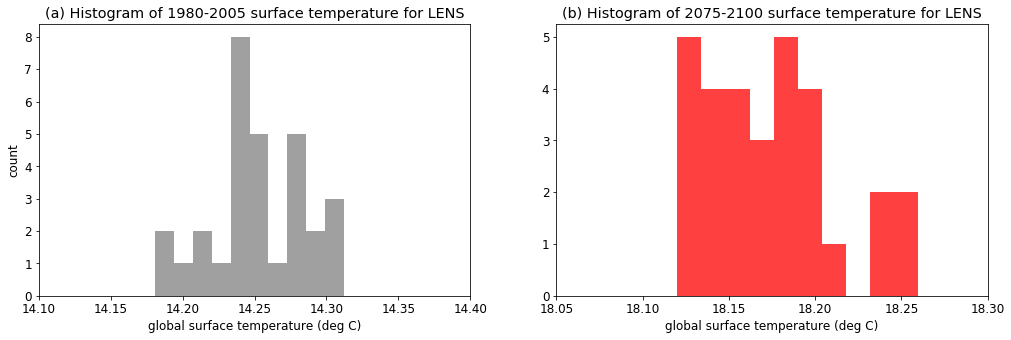

In [106]:
# create histograms of 1980-2005 and 2075-2100 surface temperatures
plt.figure(figsize=(17,5))

# Let's use subplots!

# 1980-2005
plt.subplot(1,2,1)
plt.hist(avg_TS_19802005-273.15,color='gray',alpha=0.75)
plt.xlim(14.1,14.4) # adjust the x-limits so that it looks nice
plt.ylabel("count")
plt.xlabel("global surface temperature (deg C)")
plt.title("(a) Histogram of 1980-2005 surface temperature for LENS")

# 2075-2100
plt.subplot(1,2,2)
plt.hist(avg_TS_20752100-273.15,color='red',alpha=0.75)
plt.xlim(18.05,18.3) # adjust the x-limits so that it looks nice
plt.xlabel("global surface temperature (deg C)")
plt.title("(b) Histogram of 2075-2100 surface temperature for LENS")

We can see the smaller standard deviations for these time periods reflected in the entire distribution.

## V. Making Comparisons

As we transition into the course material for Week 2 on hypothesis testing, let's take a look how our different means compare using a bar plot.

Bar plots require all the data to be in an array. How do we combine separate arrays into one? Try `np.stack()`.

In [29]:
# stack the pre-industral mean, the 30-member ensemble mean for 1980-2005 and for 2075-2100

TS_all = np.stack((np.mean(TS_PI)-273.15,np.mean(avg_TS_19802005)-273.15,np.mean(avg_TS_20752100)-273.15))
print(TS_all)

[13.95522461 14.25280151 18.19823608]


Now, make a bar plot of the means. Use this [link](https://www.tutorialspoint.com/matplotlib/matplotlib_bar_plot.htm) to see an example of creating a bar plot. 

Text(0.5,1,'Global surface temperature for three time periods')

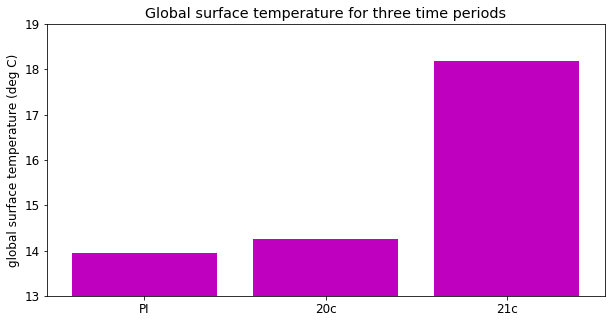

In [109]:
#Plot the pre-industrial mean surface temperature, the 30-member ensemble mean surface temperature for 1980-2005 
# and the 30-member ensemble mean surface temperature for 2075-2100.

time_period = ["PI","20c","21c"]
plt.figure(figsize=(10,5))
plt.bar(time_period,TS_all,color='m')
plt.ylim(13,19) # adjust the y-limits to make highlight differences

plt.ylabel('global surface temperature (deg C)')
plt.title("Global surface temperature for three time periods")

We will revisit this activity next week and assess to what extent these differences are statistically meaningful.